<a href="https://colab.research.google.com/github/fazmina11/fazmina-codeboosters-2026/blob/main/Day4/MiniProject_Day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install pyspark --quiet
print('PySpark installation Successfully!!')

PySpark installation Successfully!!


In [ ]:

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
spark = SparkSession.builder \
    .appName('Day4_BigData_sales') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .getOrCreate()

print(f"Spark Version: {spark.version}")
print("Spark Session: ACTIVE")
print(f"Application Name: {spark.sparkContext.appName}")

Spark Version: 4.0.2
Spark Session: ACTIVE
Application Name: Day4_BigData_sales


In [ ]:

df=spark.read\
.option('header','true')\
.option('inferSchema','true')\
.csv('/content/drive/MyDrive/Copy of large_sales_data.csv')

print('Dataframe')
print(f'Rows: {df.count()}')
print(f'Columns: {len(df.columns)}')
print(F'Names: {df.columns}')
print() #just for blank space between lines
df.printSchema()

Dataframe
Rows: 5000
Columns: 13
Names: ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [ ]:

df_new = df \
.groupBy('region') \
.agg(
    F.sum('revenue').alias ('total_revenue')
    )\
.orderBy('total_revenue',ascending=False)

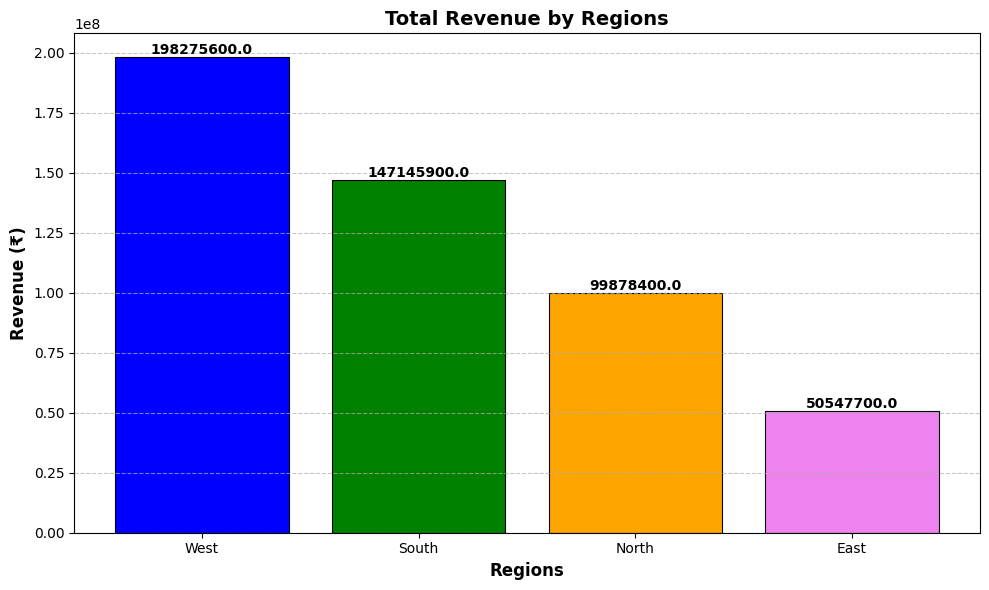

In [ ]:
df_new_pd = df_new.toPandas() # Convert Spark DataFrame to Pandas DataFrame

fig, ax = plt.subplots(figsize=(10, 6))
bar_colours = ['blue', 'green', 'orange', 'violet']

bars = ax.bar(
    df_new_pd['region'],
    df_new_pd['total_revenue'],
    color=bar_colours,
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

ax.set_xlabel('Regions', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue (₹)', fontsize=12, fontweight='bold')
ax.set_title('Total Revenue by Regions', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()